# **Segundo parcial - Aprendizaje automático**

# Selección de Feature

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# --- AVISO: Este es un bloque de código completo y autónomo ---

# --- PASO 0: IMPORTACIÓN DE LIBRERÍAS ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.feature_selection import RFE, SelectFromModel

# --- PASO 1: CARGA Y LIMPIEZA DE DATOS ---
try:
    # Se carga el archivo CSV que subiste
    df = pd.read_csv("/content/drive/Shareddrives/ap automatico/Tabla_GDP.csv")
    df.columns = df.columns.str.strip()
    print("Dataset 'Tabla_GDP.csv.csv' cargado exitosamente.")
except FileNotFoundError:
    print("Error: Asegúrate de que el archivo 'Tabla_GDP.csv.csv' esté en el entorno de ejecución.")
    # Si da error, se detiene la ejecución.
    exit()

# Para que los modelos de selección funcionen, se deben eliminar las filas donde el objetivo 'gdp' es nulo.
df.dropna(subset=['gdp'], inplace=True)


# --- PASO 2: PREPROCESAMIENTO ---
print("\n--- Preprocesando los datos con todas las variables numéricas ---")

# 'y' es la variable objetivo
y = df['gdp']

# 'X' son todas las demás columnas, excepto 'gdp' y la categórica 'province'
X = df.drop(columns=['gdp', 'province'])

# Se guardan los nombres de las características para usarlos en los resultados
feature_names = X.columns.tolist()

# Se dividen los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Se imputan los valores faltantes en X
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)

# Se escalan los datos de X
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)

print("Preprocesamiento completado.")
print("-" * 50)


# --- PASO 3: APLICACIÓN DE LAS TRES TÉCNICAS SOLICITADAS ---

# --- Técnica 1: LassoRegression ---
print("\n--- 1. Resultados de LassoRegression ---")
# Se instancia el modelo Lasso. Un alpha pequeño le da menos penalización.
# Se usa 'max_iter' para asegurar que el modelo converja.
lasso_model = Lasso(alpha=1.0, max_iter=10000, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

# Se crea una tabla de resultados para Lasso
lasso_results = pd.DataFrame({'Variable': feature_names, 'Coeficiente Lasso': lasso_model.coef_})
variables_descartadas_lasso = lasso_results[lasso_results['Coeficiente Lasso'] == 0]
variables_seleccionadas_lasso = lasso_results[lasso_results['Coeficiente Lasso'] != 0]

print("Variables seleccionadas por Lasso (coeficiente != 0):")
print(variables_seleccionadas_lasso)
print("\nVariables descartadas por Lasso (coeficiente == 0):")
print(variables_descartadas_lasso)
print("-" * 50)


# --- Técnica 2: RFE (Recursive Feature Elimination) ---
print("\n--- 2. Resultados de RFE ---")
# Se usa un modelo base para que RFE lo entrene repetidamente
estimator_for_rfe = LinearRegression()
# Se configura RFE para que seleccione las 3 mejores variables
rfe_selector = RFE(estimator=estimator_for_rfe, n_features_to_select=3, step=1)
rfe_selector.fit(X_train_scaled, y_train)

# Se muestran las variables que RFE eligió
rfe_support = rfe_selector.support_
rfe_selected_features = [feature for feature, selected in zip(feature_names, rfe_support) if selected]
print(f"Las {len(rfe_selected_features)} variables seleccionadas por RFE son:")
print(rfe_selected_features)
print("-" * 50)


# --- Técnica 3: SelectFromModel ---
print("\n--- 3. Resultados de SelectFromModel ---")
# Se usa un modelo base para que SelectFromModel determine la importancia
estimator_for_sfm = LinearRegression()
sfm_selector = SelectFromModel(estimator=estimator_for_sfm)
sfm_selector.fit(X_train_scaled, y_train)

# Se muestran las variables que SelectFromModel eligió
sfm_support = sfm_selector.get_support()
sfm_selected_features = [feature for feature, selected in zip(feature_names, sfm_support) if selected]
print(f"Las {len(sfm_selected_features)} variables seleccionadas por SelectFromModel son:")
print(sfm_selected_features)
print("-" * 50)

Dataset 'Tabla_GDP.csv.csv' cargado exitosamente.

--- Preprocesando los datos con todas las variables numéricas ---
Preprocesamiento completado.
--------------------------------------------------

--- 1. Resultados de LassoRegression ---
Variables seleccionadas por Lasso (coeficiente != 0):
                 Variable  Coeficiente Lasso
0              illiteracy      -1.661134e+06
1                 poverty      -8.968920e+05
2         deficient_infra       1.224397e+06
3          school_dropout      -2.712292e+05
4           no_healthcare      -1.470774e+06
5            birth_mortal      -5.499419e+05
6                     pop       1.263246e+07
7  movie_theatres_per_cap       1.900362e+06
8         doctors_per_cap       1.852848e+06

Variables descartadas por Lasso (coeficiente == 0):
Empty DataFrame
Columns: [Variable, Coeficiente Lasso]
Index: []
--------------------------------------------------

--- 2. Resultados de RFE ---
Las 3 variables seleccionadas por RFE son:
['illiteracy', 

# Regresion Lineal con pop y illiteracy

---



Dataset 'Tabla_GDP.csv.csv' cargado exitosamente.

--- Preprocesando los datos con las variables seleccionadas: 'pop' e 'illiteracy' ---
Preprocesamiento completado.
--------------------------------------------------

--- Entrenando el nuevo modelo de Regresión Lineal ---
Modelo entrenado.
--------------------------------------------------

--- Evaluando el rendimiento del nuevo modelo ---
Métricas de prueba del nuevo modelo:
Métrica        Valor
     R² 9.892202e-01
    MSE 1.456446e+14
   RMSE 1.206833e+07
    MAE 1.000940e+07
--------------------------------------------------

--- Coeficientes del Modelo ---
Estos valores nos dicen el impacto de cada variable en el PBI:
pop           1.410788e+07
illiteracy   -5.435332e+06
dtype: float64
Intercepto (Valor base del PBI): 16,455,920.87
--------------------------------------------------

--- Gráfico de Rendimiento: Valores Reales vs. Predicciones ---


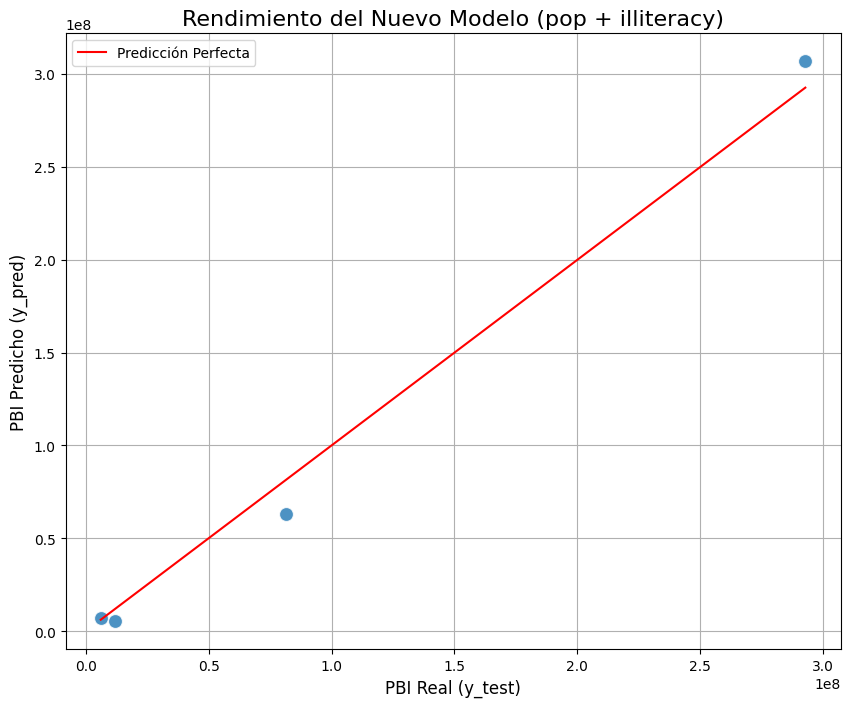

In [3]:

# --- PASO 0: IMPORTACIÓN DE LIBRERÍAS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --- PASO 1: CARGA Y LIMPIEZA DE DATOS ---
try:
    df = pd.read_csv("/content/drive/Shareddrives/ap automatico/Tabla_GDP.csv")
    df.columns = df.columns.str.strip()
    print("Dataset 'Tabla_GDP.csv.csv' cargado exitosamente.")
except FileNotFoundError:
    print("Error: Asegúrate de que el archivo 'Tabla_GDP.csv.csv' esté en el entorno de ejecución.")
    exit()

# Limpieza de la variable objetivo: se eliminan las filas donde 'gdp' es nulo.
df.dropna(subset=['gdp'], inplace=True)


# --- PASO 2: PREPROCESAMIENTO CON LAS NUEVAS VARIABLES ---
print("\n--- Preprocesando los datos con las variables seleccionadas: 'pop' e 'illiteracy' ---")

# Definimos las nuevas características seleccionadas
features = ['pop', 'illiteracy']
target = 'gdp'

y = df[target]
X = df[features]

# Se dividen los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Se imputan posibles valores faltantes en 'pop' o 'illiteracy'
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Se escalan las nuevas características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Preprocesamiento completado.")
print("-" * 50)


# --- PASO 3: ENTRENAMIENTO DEL NUEVO MODELO DE REGRESIÓN LINEAL ---
print("\n--- Entrenando el nuevo modelo de Regresión Lineal ---")

new_linear_model = LinearRegression()
new_linear_model.fit(X_train_scaled, y_train)

print("Modelo entrenado.")
print("-" * 50)


# --- PASO 4: EVALUACIÓN DEL NUEVO MODELO ---
print("\n--- Evaluando el rendimiento del nuevo modelo ---")
y_pred = new_linear_model.predict(X_test_scaled)

# Calculamos las métricas clave
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# Mostramos los resultados en una tabla
results_df = pd.DataFrame({
    'Métrica': ['R²', 'MSE', 'RMSE', 'MAE'],
    'Valor': [r2, mse, rmse, mae]
})

print("Métricas de prueba del nuevo modelo:")
print(results_df.to_string(index=False))
print("-" * 50)

# --- PASO 5: INTERPRETACIÓN DE COEFICIENTES ---
# Vemos qué aprendió el modelo sobre el impacto de cada variable
coeficientes = pd.Series(new_linear_model.coef_, index=features)
print("\n--- Coeficientes del Modelo ---")
print("Estos valores nos dicen el impacto de cada variable en el PBI:")
print(coeficientes)
print(f"Intercepto (Valor base del PBI): {new_linear_model.intercept_:,.2f}")
print("-" * 50)


# --- PASO 6: VISUALIZACIÓN DEL RENDIMIENTO ---
print("\n--- Gráfico de Rendimiento: Valores Reales vs. Predicciones ---")
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, s=100, alpha=0.8)

# Línea de predicción perfecta
perfect_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(perfect_line, perfect_line, color='red', label='Predicción Perfecta')

plt.title('Rendimiento del Nuevo Modelo (pop + illiteracy)', fontsize=16)
plt.xlabel('PBI Real (y_test)', fontsize=12)
plt.ylabel('PBI Predicho (y_pred)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()